拟合出的系数：a=2.08, b=1.57


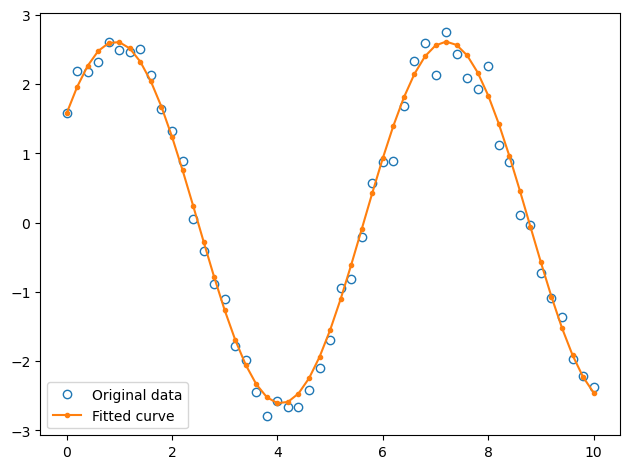

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 合成数据: y = 2*sin(x) + 1.5*cos(x) + 高斯噪声（均值为0，标准差为0.2）
x = np.linspace(0, 10, 51) # 从[0,10]中均匀采样51个点，步长为0.05
y = 2 * np.sin(x) + 1.5 * np.cos(x) + np.random.normal(0, 0.2, len(x))
# 2. 构造“设计矩阵”，第1列是sin(x)，第2列是cos(x)
A = np.column_stack([np.sin(x), np.cos(x)])
# 3. 求解 A * [a, b].T = y, 返回值第一个是系数向量
coeffs, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
a, b = coeffs
print(f"拟合出的系数：a={a:.2f}, b={b:.2f}")

y_fit = a*np.sin(x) + b*np.cos(x)
plt.plot(x, y, 'o', mfc='none', label='Original data')
plt.plot(x, y_fit, '.-', label='Fitted curve')
plt.legend()
plt.tight_layout()
plt.savefig('p-lstsq.png')